# Transcript Intelligence — analysis notebook
**Run this notebook top-to-bottom (`Run All`).** The first code section builds `outputs/meetings.parquet` automatically.
**Open and run this notebook from:** `interview-assignment/notebooks/`.
## Sections
| # | Topic |
|---:|---|
| **1** | Run pipeline (rebuild Parquet / CSV) |
| **2** | Load meetings · category preview |
| **3** | Sentiment explorer (per call + speakers) |
| **4** | Ask the transcript (LLM chatbot on `transcript.json`) |
| **5** | Top 5 positive / negative calls |
| **6** | Chart · tone by primary category |


## 1 — Run pipeline

Rebuilds `../outputs/meetings.parquet` and `meetings.csv` from `../dataset/` (or set env overrides in README).


In [1]:
import sys
from pathlib import Path

# If kernel cwd is notebooks/, add interview-assignment/src to path for dev without install
root = Path.cwd()
if root.name == "notebooks":
    sys.path.insert(0, str((root.parent / "src").resolve()))

from transcript_intel.pipeline import run_pipeline

out = run_pipeline()
print(out)

[pipeline] Processing 100 meeting folders...
[pipeline] [1/100] 01KQ03B0303900521BB089CA category=Detect outage
[pipeline] [5/100] 01KQ0F8AFF3DA34FD4580008 category=Aegis
[pipeline] [10/100] 01KQ1DE954A807A5D2653175 category=Comply
[pipeline] [15/100] 01KQ2B4878EC7B3EE5547007 category=Aegis
[pipeline] [20/100] 01KQ38C4101D6774F2F02331 category=Detect outage
[pipeline] [25/100] 01KQ3D8C1EF16C042F31FAFD category=Aegis
[pipeline] [30/100] 01KQ4529010F423FD9DB40BD category=Others
[pipeline] [35/100] 01KQ4D01DCB15C69672AB5AF category=Comply
[pipeline] [40/100] 01KQ54917E3931712516916D category=Comply
[pipeline] [45/100] 01KQ5A966832A146DA4B7D41 category=Aegis
[pipeline] [50/100] 01KQ5F364545B542671FF9CE category=Support case
[pipeline] [55/100] 01KQ764171AC27A3A94DC695 category=Others
[pipeline] [60/100] 01KQ7F58A2E07B857C24624D category=Others
[pipeline] [65/100] 01KQ8D9A06510DD623EFB1A6 category=Aegis
[pipeline] [70/100] 01KQ9BB82FD97C9607D57E90 category=Aegis
[pipeline] [75/100] 01KQA7DF

## 2 — Load meetings · category preview

Validates parquet shape and shows a compact table: call type, primary category, subthemes/topics.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", 120)

meetings_path = Path("../outputs/meetings.parquet")
if not meetings_path.exists():
    raise FileNotFoundError(f"Missing file: {meetings_path}. Run pipeline first.")

df = pd.read_parquet(meetings_path)
print("shape:", df.shape)
print("columns:", len(df.columns))

# Part A preview: categorization-focused columns only
from IPython.display import HTML, display
import html

part_a_cols = [
    "meeting_id",
    "title",
    "call_type",
    "primary_category",
    "secondary_categories",
    "subthemes",
]

part_a = df[part_a_cols].head(20).copy()
# Compact ID for display only (keep full ID in underlying df)
part_a["meeting_id"] = part_a["meeting_id"].astype(str).str[-4:]


def _parse_tags(value: object) -> list[str]:
    if isinstance(value, list):
        return [str(v).strip() for v in value if str(v).strip()]
    if value is None:
        return []

    text = str(value).strip()
    if not text:
        return []

    flat = text.replace("\\n", " ").replace("\n", " ").strip()

    # Prefer quoted segments: handles strings like
    # "['a' 'b' 'c']" or "a' 'b' 'c".
    if "'" in flat:
        import re

        quoted = [m.strip() for m in re.findall(r"'([^']+)'", flat) if m.strip()]

        # Recover possible first token before the first quote (when opening quote is missing).
        prefix = flat.split("'", 1)[0].strip(" []\",'")
        if prefix:
            quoted = [prefix] + quoted

        if quoted:
            return quoted

    # Fallback for comma-separated values.
    if "," in flat:
        return [p.strip().strip("\"'") for p in flat.strip("[]").split(",") if p.strip().strip("\"'")]

    return [flat.strip("[]\"'")]


def _subthemes_cell(value: object) -> str:
    tags = _parse_tags(value)
    if not tags:
        return ""
    bullets = "".join(f"<li style='text-align: left;'>{html.escape(tag)}</li>" for tag in tags)
    return (
        "<details>"
        "<summary>View subthemes</summary>"
        f"<ul style='margin-top: 6px; padding-left: 18px; text-align: left; list-style-position: outside;'>{bullets}</ul>"
        "</details>"
    )


part_a["subthemes"] = part_a["subthemes"].apply(_subthemes_cell)

# Hide secondary_categories from this compact UI view (still available in df/part_a)
display_cols = [
    "meeting_id",
    "title",
    "call_type",
    "primary_category",
    "subthemes",
]

html_table = part_a[display_cols].to_html(escape=False, index=False)
display(HTML(html_table))

shape: (100, 21)
columns: 21


meeting_id,title,call_type,primary_category,subthemes
89CA,Detect Outage - Remediation Plan Review,incident_cross_function,Detect outage,View subthemesoutage remediationincident responsecustomer communicationsecurity monitoringpostmortem planning
7C35,Support Case #9279 - Summit Trust Billing Inquiry,support,Support case,View subthemesbilling disputeseat overagemigration cleanupidentity managementbilling adjustment
40CA,Weekly Engineering Standup,internal_ops,Others,View subthemespipeline reliabilitykafka configurationsprint planningcomply v2 launchresource allocation
22CA,Aegis / Redwood Clinical - ISO 27001 Preparation,customer_external,Aegis,View subthemesiso 27001compliance reportingonboardinghealthcaremulti-framework coverage
0008,Aegis / Cobalt Software - Q2 Planning,customer_external,Aegis,View subthemesrenewaloutagecompetitive threatcompliancecloud expansion
FEC8,SOC 2 Audit Preparation - Internal,internal_ops,Others,View subthemessoc 2 auditaccess controlchange managementincident trackingvendor management
B60D,Support Case #6977 - Brightpath Commerce Slow Backup Performance,support,Support case,View subthemesbackup performanceagent version updatetechnical issuecustomer retentionnotification gap
D8F5,Aegis / Atlas Precision - Contract Discussion,customer_external,Aegis,View subthemesrenewalbilling disputeoverage chargescompliancecontract negotiation
98C9,Aegis / Quantum Edge - Renewal Concerns,customer_external,Aegis,View subthemesoutagerenewalcompliancecompetitive evaluationpricing
3175,Comply v2 - Launch Readiness Review,internal_ops,Comply,View subthemeslaunch readinesscompliance reportingapi rate limitingdocumentationincident impact


## 3 — Sentiment explorer

Per-call `pct_*`, `aggregated_label`, expandable per-speaker breakdown.


In [ ]:
from IPython.display import HTML, display
import html

cols = [
    "meeting_id",
    "primary_category",
    "aggregated_label",
    "pct_positive",
    "pct_neutral",
    "pct_negative",
    "speaker_count",
    "speaker_sentiment",
]

v = df[cols].head(20).copy()
v["meeting_id"] = v["meeting_id"].astype(str).str[-4:]


def _normalize_speakers(value: object) -> list[dict]:
    if value is None:
        return []
    if isinstance(value, list):
        return [x for x in value if isinstance(x, dict)]
    if isinstance(value, tuple):
        return [x for x in value if isinstance(x, dict)]
    if isinstance(value, str):
        text = value.strip()
        if not text:
            return []
        try:
            import json as _json
            parsed = _json.loads(text)
            if isinstance(parsed, list):
                return [x for x in parsed if isinstance(x, dict)]
        except Exception:
            pass
        try:
            import ast as _ast
            parsed = _ast.literal_eval(text)
            if isinstance(parsed, list):
                return [x for x in parsed if isinstance(x, dict)]
        except Exception:
            pass
    try:
        return [x for x in list(value) if isinstance(x, dict)]
    except Exception:
        return []


def speaker_details_cell(speakers):
    speaker_rows = _normalize_speakers(speakers)
    if len(speaker_rows) == 0:
        return ""

    rows = []
    for s in speaker_rows:
        rows.append(
            "<tr>"
            f"<td style='text-align:left;'>{html.escape(str(s.get('speaker_name', '')))}</td>"
            f"<td>{int(s.get('n_utterances', 0) or 0)}</td>"
            f"<td>{float(s.get('turn_share', 0.0) or 0.0):.2f}</td>"
            f"<td>{float(s.get('pct_positive', 0.0) or 0.0):.2f}</td>"
            f"<td>{float(s.get('pct_neutral', 0.0) or 0.0):.2f}</td>"
            f"<td>{float(s.get('pct_negative', 0.0) or 0.0):.2f}</td>"
            f"<td>{html.escape(str(s.get('dominant_sentiment', '')))}</td>"
            f"<td>{'yes' if s.get('is_sparse', False) else 'no'}</td>"
            "</tr>"
        )
    table = (
        "<table style='border-collapse: collapse; width: 100%; font-size: 12px;'>"
        "<thead><tr>"
        "<th style='text-align:left;'>speaker</th>"
        "<th>n</th><th>turn_share</th><th>pos</th><th>neu</th><th>neg</th><th>dominant</th><th>sparse</th>"
        "</tr></thead>"
        f"<tbody>{''.join(rows)}</tbody></table>"
    )
    return (
        "<details>"
        "<summary>View speaker sentiment</summary>"
        f"<div style='margin-top: 6px;'>{table}</div>"
        "</details>"
    )


v["speaker_sentiment_detail"] = v["speaker_sentiment"].apply(speaker_details_cell)
show_cols = [
    "meeting_id",
    "primary_category",
    "aggregated_label",
    "pct_positive",
    "pct_neutral",
    "pct_negative",
    "speaker_count",
    "speaker_sentiment_detail",
]
display(HTML(v[show_cols].to_html(escape=False, index=False)))

## 4 — Ask the transcript (chatbot)

Grounded Q&A over raw `dataset/<id>/transcript.json` · needs `OPENAI_API_KEY` · optional in-memory cache per question.


In [ ]:
import hashlib
import html
import json
import os
from pathlib import Path

import ipywidgets as widgets
import pandas as pd
from IPython.display import HTML, Markdown, display
from pydantic import BaseModel, Field
from typing import Literal

# Allow this cell to run standalone even if df is not yet in memory.
if "df" not in globals():
    meetings_path = Path("../outputs/meetings.parquet")
    if not meetings_path.exists():
        raise FileNotFoundError(f"Missing file: {meetings_path}. Run pipeline first.")
    df = pd.read_parquet(meetings_path)

_root = Path.cwd()
if _root.name == "notebooks":
    DATASET_DIR = (_root.parent / "dataset").resolve()
else:
    DATASET_DIR = (_root / "dataset").resolve()

_TRANSCRIPT_MAX_CHARS = 36_000


class TranscriptQuote(BaseModel):
    speaker: str = ""
    quote: str = ""


class TranscriptAnswer(BaseModel):
    """Structured answer grounded in the meeting transcript only."""

    answer: str = Field(description="Direct answer to the user's question.")
    grounded: Literal["yes", "partial", "no"] = Field(
        description="yes if fully supported by transcript; partial if inferred; no if not in transcript."
    )
    supporting_quotes: list[TranscriptQuote] = Field(
        default_factory=list,
        description="Up to 3 short verbatim snippets from the transcript that support the answer.",
    )
    caveats: str = Field(
        default="",
        description="One short sentence if context was truncated or evidence is weak.",
    )


_qa_cache: dict[str, TranscriptAnswer] = {}


def _load_transcript_formatted(meeting_id: str) -> tuple[str, bool]:
    """Return (dialogue text, truncated_flag)."""
    path = DATASET_DIR / str(meeting_id) / "transcript.json"
    if not path.is_file():
        return (f"[No transcript.json found at {path}]", False)
    raw = json.loads(path.read_text(encoding="utf-8"))
    rows = raw.get("data") if isinstance(raw, dict) else None
    if not isinstance(rows, list):
        return ("[transcript.json has no data array]", False)
    lines: list[str] = []
    for row in rows:
        if not isinstance(row, dict):
            continue
        name = str(row.get("speaker_name") or "").strip()
        sid = row.get("speaker_id")
        who = name or (f"speaker_{sid}" if sid is not None else "unknown")
        text = (row.get("sentence") or row.get("text") or "").strip()
        if text:
            lines.append(f"{who}: {text}")
    blob = "\n".join(lines)
    if len(blob) <= _TRANSCRIPT_MAX_CHARS:
        return blob, False
    return blob[:_TRANSCRIPT_MAX_CHARS] + "\n\n[... transcript truncated for model context ...]", True


def _cache_key(meeting_id: str, question: str) -> str:
    h = hashlib.sha256(f"{meeting_id}\n{question.strip().lower()}".encode()).hexdigest()[:24]
    return f"{meeting_id}:{h}"


def _render_answer(meeting_id: str, question: str, result: TranscriptAnswer, truncated: bool, from_cache: bool) -> None:
    meta = "(from cache)" if from_cache else "(fresh)"
    trunc_note = " Transcript was truncated for this prompt." if truncated else ""
    caveats = ""
    if result.caveats or trunc_note:
        caveats = f"\n\n*Note:* {result.caveats}{trunc_note}".strip()

    display(
        Markdown(
            f"""### Answer for `{str(meeting_id)[-4:]}` {meta}

**Question:** {question}

**Grounded in transcript:** `{result.grounded}`  

{result.answer}{caveats}
"""
        )
    )
    if result.supporting_quotes:
        lis: list[str] = []
        for q in result.supporting_quotes[:3]:
            sp = html.escape(str(q.speaker or "speaker"))
            qt = html.escape(str(q.quote or ""))
            lis.append(
                "<li style='margin-bottom:10px;line-height:1.45;color:#111827;text-align:left;'>"
                f"<strong>{sp}:</strong> {qt}</li>"
            )
        fragment = "".join(lis)
        display(
            HTML(
                "<div style='background:#f4f4f6;border-left:4px solid #64748b;color:#111827;"
                "padding:12px 14px;margin-top:12px;font-size:14px;text-align:left;' role='note'>"
                "<strong style='color:#0f172a;'>Evidence from transcript</strong>"
                f"<ul style='margin:10px 0 0;padding-left:20px;'>{fragment}</ul></div>"
            )
        )


opts = []
for _, r in df[["meeting_id", "title"]].drop_duplicates().sort_values("meeting_id").iterrows():
    mid = str(r["meeting_id"])
    t = str(r["title"])
    short = (t[:70] + "...") if len(t) > 70 else t
    opts.append((f"{mid[-4:]} | {short}", mid))

meeting_dropdown = widgets.Dropdown(options=opts, description="Call:", layout=widgets.Layout(width="90%"))
question_box = widgets.Textarea(
    value="",
    placeholder="e.g. What root cause was discussed? What did the customer commit to?",
    description="Question:",
    layout=widgets.Layout(width="90%", height="80px"),
)
ask_btn = widgets.Button(description="Ask transcript", button_style="primary")
output = widgets.Output()


def _on_ask(_):
    with output:
        output.clear_output(wait=True)
        meeting_id = meeting_dropdown.value
        question = (question_box.value or "").strip()
        if not meeting_id:
            print("Select a call first.")
            return
        if not question:
            print("Enter a question.")
            return

        key = _cache_key(meeting_id, question)
        if key in _qa_cache:
            _, truncated = _load_transcript_formatted(meeting_id)
            _render_answer(meeting_id, question, _qa_cache[key], truncated, from_cache=True)
            return

        if not os.getenv("OPENAI_API_KEY"):
            print("Missing OPENAI_API_KEY. Set it, then click Ask transcript again.")
            return

        try:
            from langchain_core.prompts import ChatPromptTemplate
            from langchain_openai import ChatOpenAI
        except Exception as e:
            print(f"Missing LLM dependencies: {e}")
            return

        row = df.loc[df["meeting_id"].astype(str) == str(meeting_id)]
        title = str(row.iloc[0].get("title", "")) if len(row) else ""
        transcript_text, truncated = _load_transcript_formatted(meeting_id)

        try:
            model = os.getenv("OPENAI_MODEL", "gpt-4o-mini")
            llm = ChatOpenAI(model=model, temperature=0.1)
            structured = llm.with_structured_output(TranscriptAnswer)
            prompt = ChatPromptTemplate.from_messages(
                [
                    (
                        "system",
                        "You answer questions using ONLY the meeting transcript dialogue below. "
                        "Do not use outside knowledge or invent facts. "
                        "If the answer is not explicitly in the transcript, set grounded=no and say what is unknown. "
                        "supporting_quotes must be short verbatim excerpts from the transcript (same wording). "
                        "Do not paste the entire transcript back.",
                    ),
                    (
                        "human",
                        "Meeting title: {title}\n"
                        "Meeting id: {mid}\n\n"
                        "Transcript (speaker turns):\n---\n{transcript}\n---\n\n"
                        "User question: {question}\n",
                    ),
                ]
            )
            chain = prompt | structured
            print("Thinking over transcript...")
            result: TranscriptAnswer = chain.invoke(
                {
                    "title": title,
                    "mid": str(meeting_id),
                    "transcript": transcript_text,
                    "question": question,
                }
            )
            _qa_cache[key] = result
            output.clear_output(wait=True)
            _render_answer(meeting_id, question, result, truncated, from_cache=False)
        except Exception as e:
            output.clear_output(wait=True)
            print(f"Q&A failed: {e}")


ask_btn.on_click(_on_ask)

display(
    widgets.VBox(
        [
            widgets.HTML(
                "<p><strong>Ask the transcript:</strong> questions are answered from chat logs "
                "(<code>transcript.json</code>), not from the canned summary.</p>"
            ),
            meeting_dropdown,
            question_box,
            ask_btn,
            output,
        ]
    )
)


## 5 — Top 5 positive / negative calls

Ranking by `pct_negative` / `pct_positive` · simple investor tail view.


In [ ]:
import pandas as pd
from IPython.display import display

TOP_N = 5

cols = [
    "meeting_id",
    "title",
    "primary_category",
    "pct_negative",
    "pct_positive",
    "aggregated_label",
]

most_negative = df.nlargest(TOP_N, "pct_negative")[cols].reset_index(drop=True)
most_negative["pct_negative"] = pd.to_numeric(most_negative["pct_negative"], errors="coerce")
most_negative["pct_positive"] = pd.to_numeric(most_negative["pct_positive"], errors="coerce")

most_positive = df.nlargest(TOP_N, "pct_positive")[cols].reset_index(drop=True)
most_positive["pct_negative"] = pd.to_numeric(most_positive["pct_negative"], errors="coerce")
most_positive["pct_positive"] = pd.to_numeric(most_positive["pct_positive"], errors="coerce")

print(f"Top {TOP_N} most negative-toned calls (highest pct_negative)")
display(
    most_negative.style.hide(axis="index").format(
        {"pct_negative": "{:.3f}", "pct_positive": "{:.3f}"}
    )
)

print(f"Top {TOP_N} most positive-toned calls (highest pct_positive)")
display(
    most_positive.style.hide(axis="index").format(
        {"pct_negative": "{:.3f}", "pct_positive": "{:.3f}"}
    )
)

cat_tone = (
    df.groupby("primary_category", dropna=False)
    .agg(
        n_calls=("meeting_id", "count"),
        mean_pct_negative=("pct_negative", "mean"),
        mean_pct_positive=("pct_positive", "mean"),
    )
    .reset_index()
    .sort_values("mean_pct_negative", ascending=False)
)
for c in ("mean_pct_negative", "mean_pct_positive"):
    cat_tone[c] = pd.to_numeric(cat_tone[c], errors="coerce")



Top 5 most negative-toned calls (highest pct_negative)


meeting_id,title,primary_category,pct_negative,pct_positive,aggregated_label
01KQ38C4101D6774F2F02331,INCIDENT: Detect Pipeline Failure - War Room,Detect outage,0.718,0.000,very_negative
01KQ88B8EAEAA819C26CCBE7,ESCALATION: Northstar Pharma - Detect Outage Impact on Compliance,Detect outage,0.659,0.000,very_negative
01KQ7BF0D56037FF89DC89B6,Support Case #3266 - Trailhead Marketplace Detect Alerts Not Firing,Support case,0.639,0.000,very_negative
01KQ46A9DE0AECB006D897A0,Detect Outage - Escalation Bridge,Detect outage,0.610,0.000,very_negative
01KQE110900B8A65D80AE694,Detect Outage - Root Cause Analysis,Detect outage,0.579,0.000,negative_leaning


Top 5 most positive-toned calls (highest pct_positive)


meeting_id,title,primary_category,pct_negative,pct_positive,aggregated_label
01KQA502E222E2A60330237B,Aegis / Pineridge Systems - Q1 Business Review,Aegis,0.000,0.864,very_positive
01KQAFB8DBF6E1E2FDEF0B75,Aegis / Maplewood Goods - SOC 2 Prep Review,Aegis,0.027,0.811,very_positive
01KQFFC0F889AE8CFEE7A00D,Aegis / Blackridge Investments - Renewal Discussion,Aegis,0.000,0.808,very_positive
01KQ4D01DCB15C69672AB5AF,Aegis / Clearwater Medical - Comply v2 Deployment Kickoff,Comply,0.000,0.795,very_positive
01KQ56786DD1E8A1BF174FDD,Support Case #1993 - Forge Industries Comply v2 Early Access Question,Support case,0.000,0.791,very_positive


## 6 — Chart: tone by primary category

Bar chart + table of mean negative share by `primary_category` · saves PNG under `../outputs/figures/`.


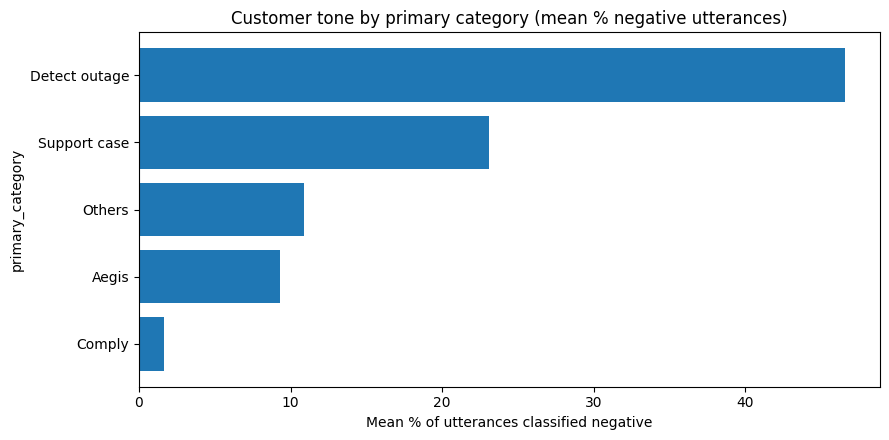

,primary_category,n_calls,mean_pct_negative,mean_pct_positive
0,Detect outage,12,0.465552,0.027473
1,Support case,27,0.231056,0.100803
2,Others,18,0.108834,0.191566
3,Aegis,35,0.093381,0.434454
4,Comply,8,0.016412,0.637548


In [ ]:
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display

fig_dir = Path("../outputs/figures")
fig_dir.mkdir(parents=True, exist_ok=True)

plot_df = cat_tone.sort_values("mean_pct_negative", ascending=True).copy()

plt.figure(figsize=(9, 4.5))
plt.barh(plot_df["primary_category"], plot_df["mean_pct_negative"] * 100.0)
plt.title("Customer tone by primary category (mean % negative utterances)")
plt.xlabel("Mean % of utterances classified negative")
plt.ylabel("primary_category")
plt.tight_layout()
plt.savefig(fig_dir / "sentiment_by_primary_category.png", dpi=150)
plt.show()

display(cat_tone.reset_index(drop=True))

